# Machine Learning Based Analysis of Study Behaviour Patterns for Student Performance Prediction

Final academic analysis notebook.

## 1. Libraries and configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 2. Load dataset

In [2]:
candidate_files = [
    Path("student_performance.csv"),
    Path("student_performance (2).csv"),
    Path("student_performance(2).csv"),
    Path("/mnt/data/student_performance(2).csv")
]

data_path = next((p for p in candidate_files if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place student_performance.csv in the same folder as this notebook.")

df = pd.read_csv(data_path)
print(f"Dataset: {data_path.name}")
print(f"Shape: {df.shape}")
df.head()

Dataset: student_performance.csv
Shape: (14003, 16)


   StudyHours  Attendance  Resources  ...  EduTech  StressLevel  FinalGrade
0          19          64          1  ...        0            1           3
1          19          64          1  ...        0            1           2
2          19          64          1  ...        1            1           0
3          19          64          1  ...        0            1           3
4          19          64          1  ...        0            1           2

[5 rows x 16 columns]

## 3. Data quality assessment

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

df.describe().T

Columns:
['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']

Missing values:
StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

Duplicate rows: 1,534


                        count       mean        std  ...   50%   75%    max
StudyHours            14003.0  19.987431   5.890637  ...  20.0  24.0   44.0
Attendance            14003.0  80.194316  11.472181  ...  80.0  90.0  100.0
Resources             14003.0   1.104406   0.697362  ...   1.0   2.0    2.0
Extracurricular       14003.0   0.594158   0.491072  ...   1.0   1.0    1.0
Motivation            14003.0   0.905806   0.695896  ...   1.0   1.0    2.0
Internet              14003.0   0.925516   0.262566  ...   1.0   1.0    1.0
Gender                14003.0   0.551953   0.497311  ...   1.0   1.0    1.0
Age                   14003.0  23.532172   3.514293  ...  24.0  27.0   29.0
LearningStyle         14003.0   1.515461   1.112941  ...   2.0   3.0    3.0
OnlineCourses         14003.0   9.891952   6.112801  ...  10.0  15.0   20.0
Discussions           14003.0   0.605870   0.488680  ...   1.0   1.0    1.0
AssignmentCompletion  14003.0  74.502535  14.632177  ...  74.0  87.0  100.0
ExamScore   

## 4. FinalGrade directional recoding

The source dataset codes the highest academic outcome with the lowest numerical grade code. The grade codes are therefore reversed so that higher numerical values represent better academic performance. The original values are retained for audit. No student changes class. ExamScore remains excluded from all predictive models to prevent target leakage.

In [4]:
df["FinalGrade_Original"] = df["FinalGrade"].copy()

grade_min = df["FinalGrade_Original"].min()
grade_max = df["FinalGrade_Original"].max()
df["FinalGrade"] = grade_max + grade_min - df["FinalGrade_Original"]

original_corr = df[["ExamScore", "FinalGrade_Original"]].corr().iloc[0, 1]
recoded_corr = df[["ExamScore", "FinalGrade"]].corr().iloc[0, 1]

print(f"Original ExamScore–FinalGrade correlation: {original_corr:.3f}")
print(f"Recoded ExamScore–FinalGrade correlation:  {recoded_corr:.3f}")

pd.crosstab(df["FinalGrade_Original"], df["FinalGrade"], rownames=["Original"], colnames=["Recoded"])

Original ExamScore–FinalGrade correlation: -0.968
Recoded ExamScore–FinalGrade correlation:  0.968


Recoded      0     1     2     3
Original                        
0            0     0     0  3832
1            0     0  3310     0
2            0  3618     0     0
3         3243     0     0     0

## 5. Data cleaning

In [5]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after duplicate removal: {rows_after:,}")
print(f"Duplicates removed: {rows_before - rows_after:,}")
print(f"Remaining missing values: {df.isna().sum().sum()}")

Rows before cleaning: 14,003
Rows after duplicate removal: 12,469
Duplicates removed: 1,534
Remaining missing values: 0


## 6. Exploratory analysis

FinalGrade
0    23.29
1    25.83
2    23.60
3    27.28
Name: proportion, dtype: float64


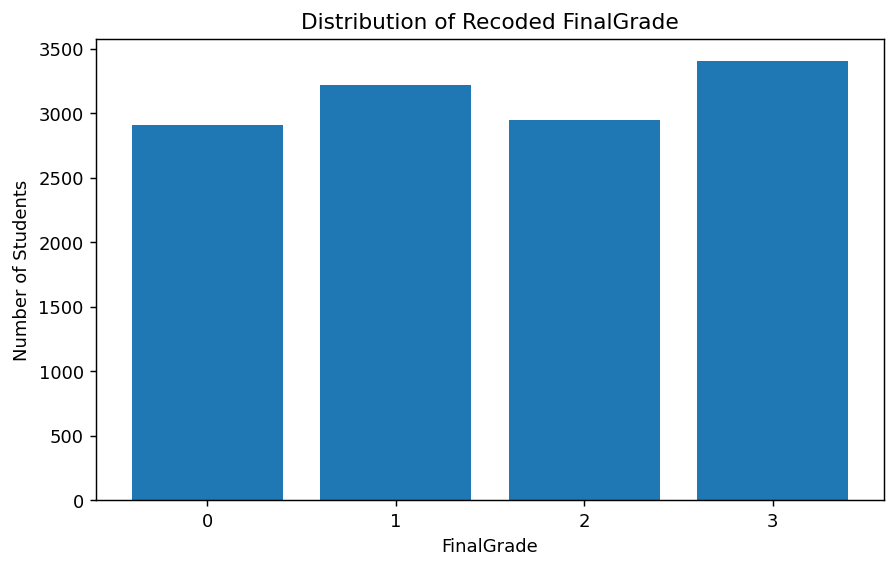

In [6]:
grade_distribution = df["FinalGrade"].value_counts().sort_index()

plt.figure(figsize=(7, 4.5))
plt.bar(grade_distribution.index.astype(str), grade_distribution.values)
plt.title("Distribution of Recoded FinalGrade")
plt.xlabel("FinalGrade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

print((df["FinalGrade"].value_counts(normalize=True).sort_index() * 100).round(2))

### ExamScore and FinalGrade relationship

In [7]:
grade_exam_summary = df.groupby("FinalGrade")["ExamScore"].agg(["count", "mean", "median", "min", "max"]).round(2)
grade_exam_summary

            count   mean  median  min  max
FinalGrade                                
0            2904  46.75    47.0   40   54
1            3221  61.88    62.0   55   69
2            2943  77.07    77.0   70   84
3            3401  92.57    93.0   85  100

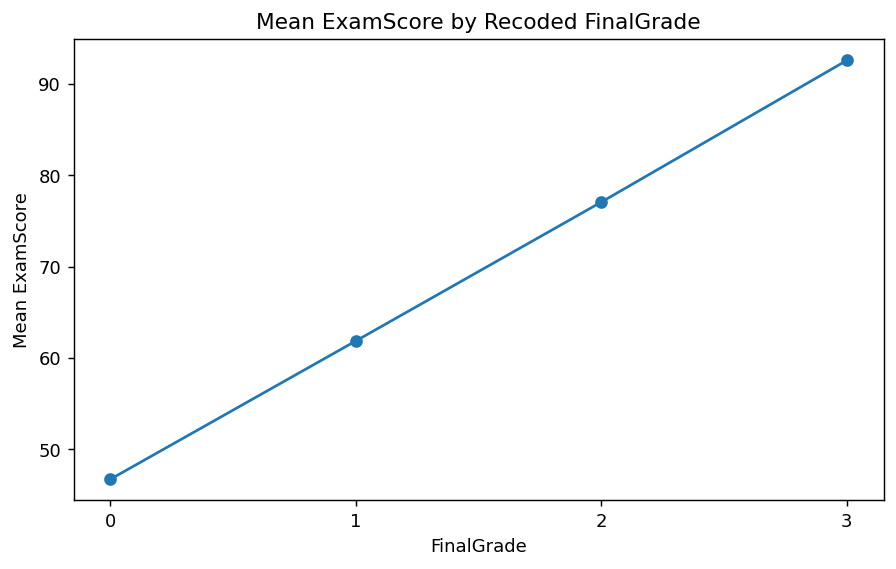

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(grade_exam_summary.index, grade_exam_summary["mean"], marker="o")
plt.title("Mean ExamScore by Recoded FinalGrade")
plt.xlabel("FinalGrade")
plt.ylabel("Mean ExamScore")
plt.xticks(grade_exam_summary.index)
plt.tight_layout()
plt.show()

### Selected behavioural variables

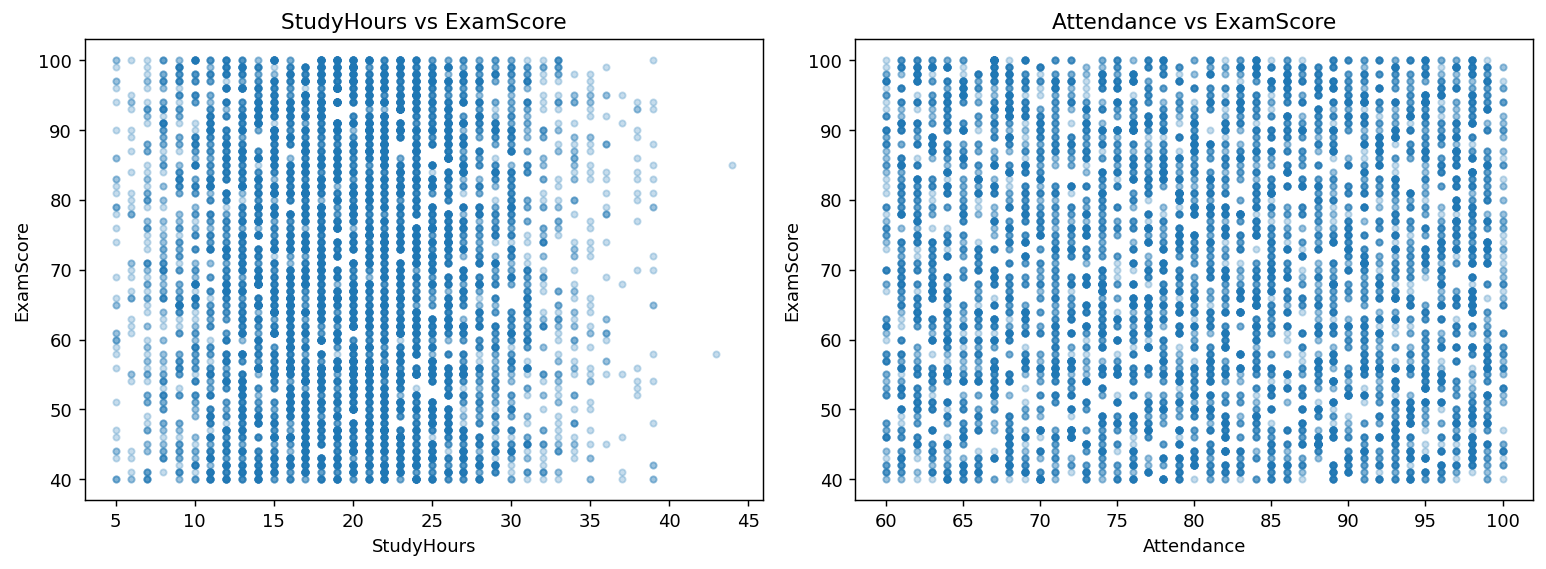

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(df["StudyHours"], df["ExamScore"], alpha=0.25, s=12)
axes[0].set_title("StudyHours vs ExamScore")
axes[0].set_xlabel("StudyHours")
axes[0].set_ylabel("ExamScore")

axes[1].scatter(df["Attendance"], df["ExamScore"], alpha=0.25, s=12)
axes[1].set_title("Attendance vs ExamScore")
axes[1].set_xlabel("Attendance")
axes[1].set_ylabel("ExamScore")

plt.tight_layout()
plt.show()

### Correlation matrix after recoding

Spearman correlation is used because the dataset contains continuous, binary and ordinal coded variables. ExamScore is included only to demonstrate the corrected direction and is excluded from all predictive models.


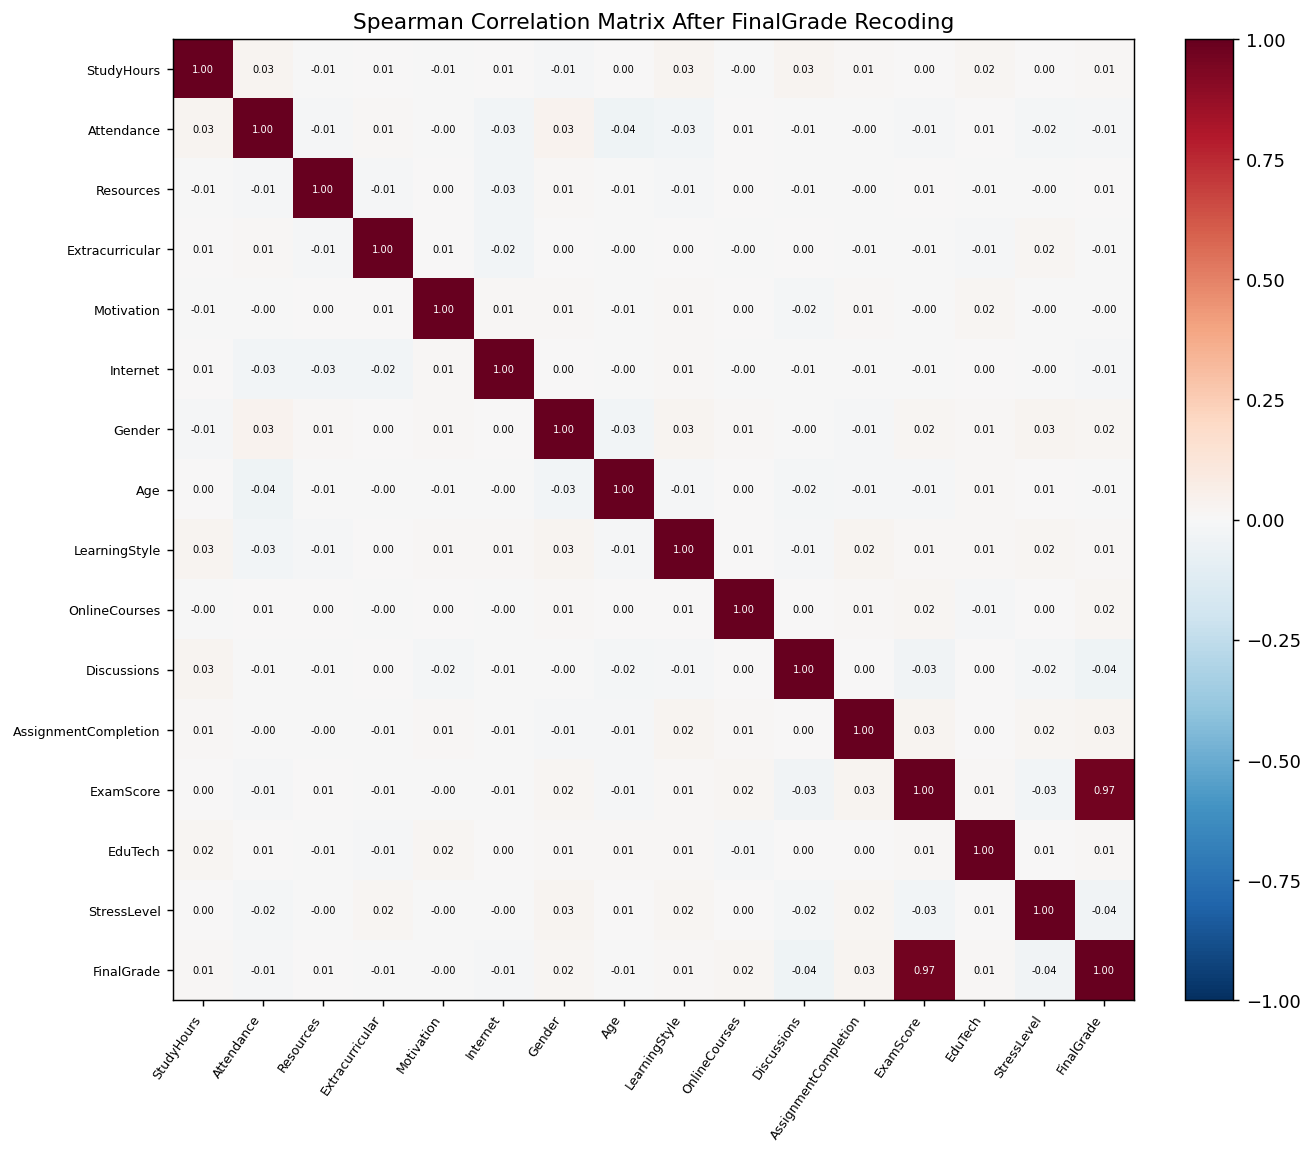

In [10]:
corr_columns = [column for column in df.columns if column != "FinalGrade_Original"]
corr_matrix = df[corr_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_columns)))
ax.set_yticks(np.arange(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=55, ha="right", fontsize=7)
ax.set_yticklabels(corr_columns, fontsize=7)
for row in range(len(corr_columns)):
    for column in range(len(corr_columns)):
        value = corr_matrix.iloc[row, column]
        colour = "white" if abs(value) > 0.55 else "black"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=5.5, color=colour)
plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.title("Spearman Correlation Matrix After FinalGrade Recoding")
plt.tight_layout()
plt.show()


### Behavioural predictors across grade classes

The following boxplots assess whether important behavioural predictors individually separate the four grade classes. Their overlap provides context for comparing the linear and nonlinear models.


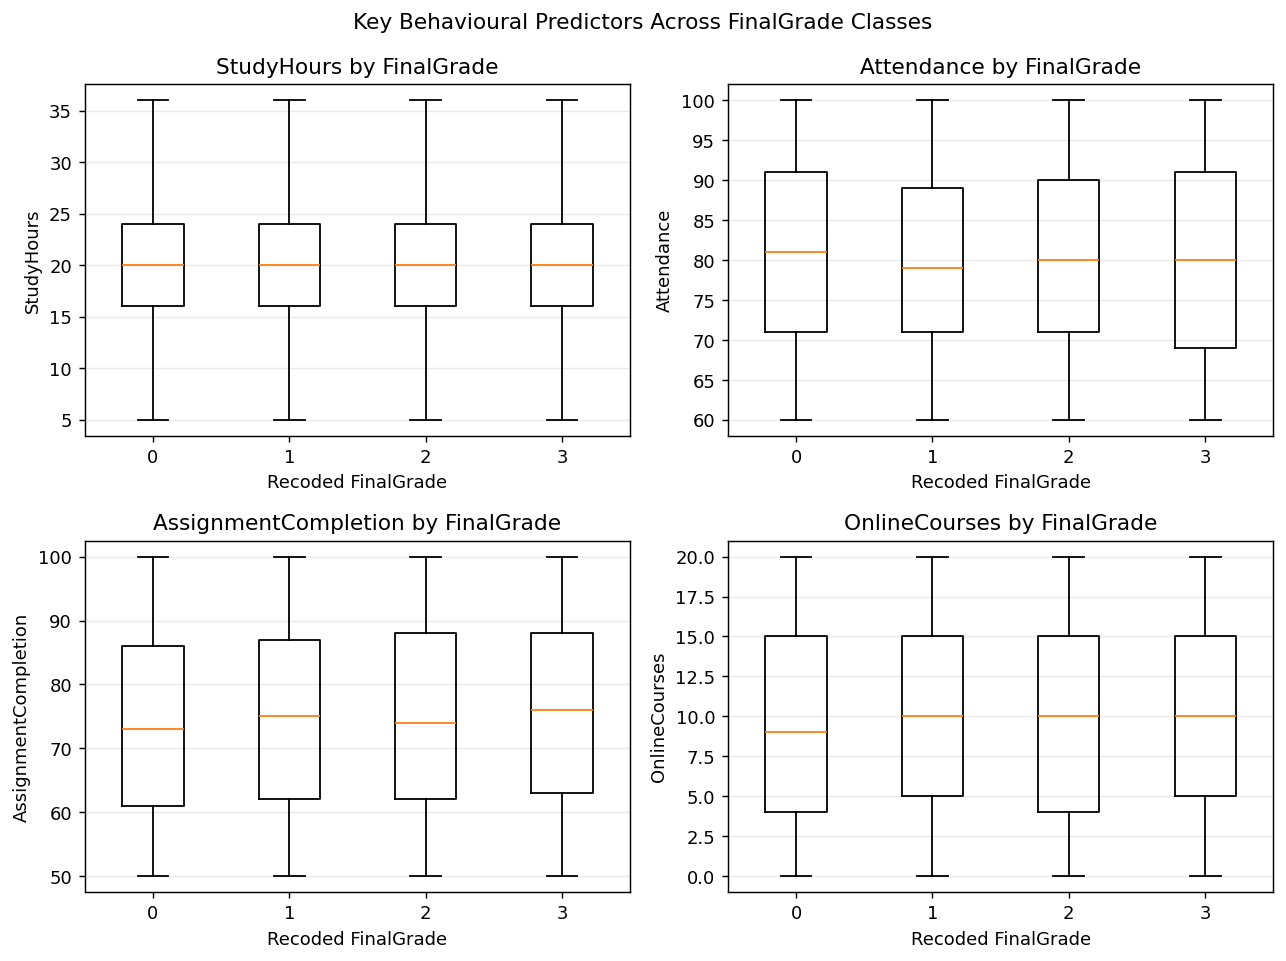

In [11]:
variables = ["StudyHours", "Attendance", "AssignmentCompletion", "OnlineCourses"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, variable in zip(axes.flat, variables):
    groups = [df.loc[df["FinalGrade"] == grade, variable].values for grade in range(4)]
    ax.boxplot(groups, labels=["0", "1", "2", "3"], showfliers=False)
    ax.set_title(f"{variable} by FinalGrade")
    ax.set_xlabel("Recoded FinalGrade")
    ax.set_ylabel(variable)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle("Key Behavioural Predictors Across FinalGrade Classes")
plt.tight_layout()
plt.show()


## 7. Feature and target definition

In [12]:
TARGET = "FinalGrade"
EXCLUDED = ["FinalGrade", "FinalGrade_Original", "ExamScore"]
FEATURES = [column for column in df.columns if column not in EXCLUDED]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Target: {TARGET}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print("ExamScore included as predictor:", "ExamScore" in X.columns)

Target: FinalGrade
Features (14): ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech', 'StressLevel']
ExamScore included as predictor: False


## 8. Train-test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True
)

print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")

Training records: 9,975
Testing records: 2,494


## 9. Logistic Regression

In [14]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print(f"Accuracy: {acc_lr:.4f}")
print(f"Weighted F1-score: {f1_lr:.4f}")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.2662
Weighted F1-score: 0.2279
              precision    recall  f1-score   support

           0       0.26      0.17      0.21       581
           1       0.24      0.25      0.24       644
           2       0.21      0.03      0.06       589
           3       0.29      0.57      0.38       680

    accuracy                           0.27      2494
   macro avg       0.25      0.25      0.22      2494
weighted avg       0.25      0.27      0.23      2494



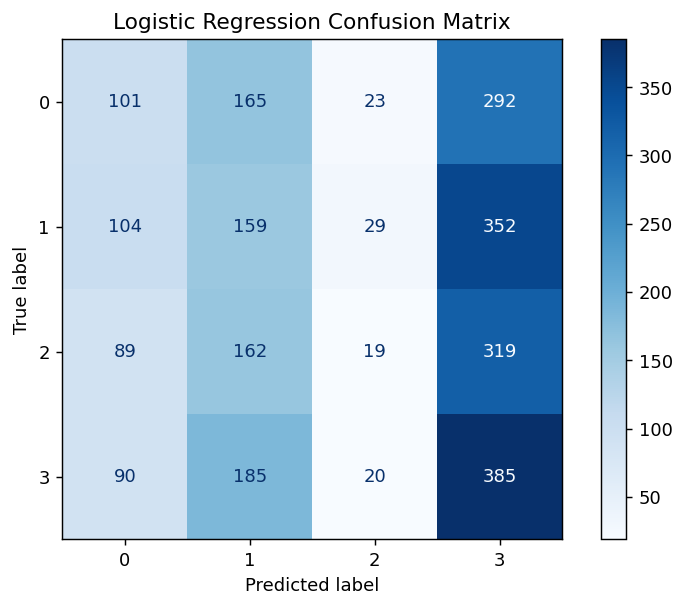

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print(f"Accuracy: {acc_rf:.4f}")
print(f"Weighted F1-score: {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8941
Weighted F1-score: 0.8940
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       581
           1       0.89      0.91      0.90       644
           2       0.90      0.86      0.88       589
           3       0.89      0.91      0.90       680

    accuracy                           0.89      2494
   macro avg       0.89      0.89      0.89      2494
weighted avg       0.89      0.89      0.89      2494



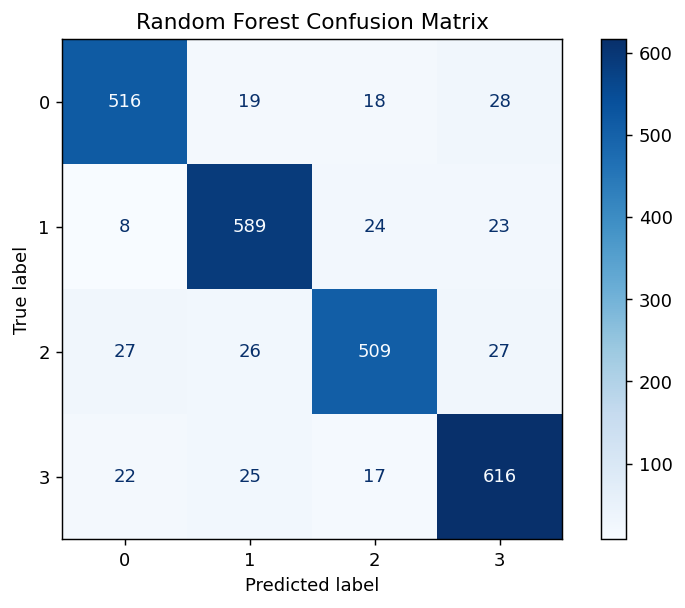

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Random Forest feature importance

                 Feature  Importance
0   AssignmentCompletion    0.160457
1             Attendance    0.152391
2             StudyHours    0.143751
3          OnlineCourses    0.137839
4                    Age    0.115230
5          LearningStyle    0.068786
6            StressLevel    0.042598
7                 Gender    0.033509
8                EduTech    0.030320
9              Resources    0.029536
10            Motivation    0.028838
11           Discussions    0.028803
12       Extracurricular    0.018859
13              Internet    0.009084

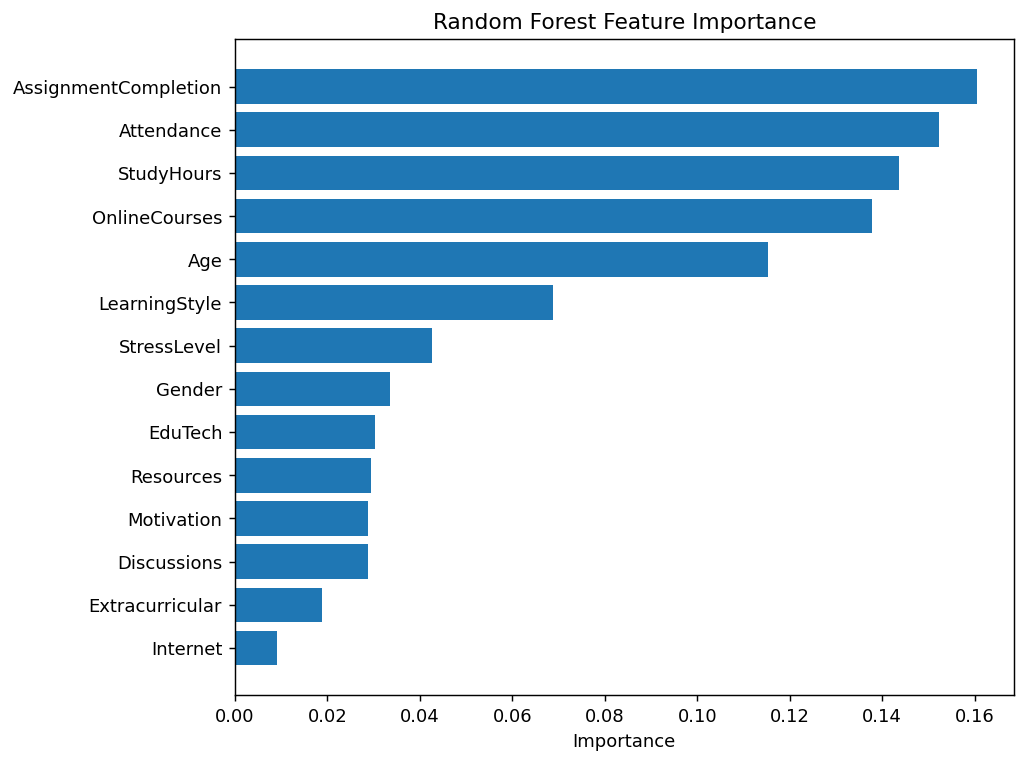

In [18]:
rf_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

rf_importance.sort_values("Importance", ascending=False).reset_index(drop=True)

## 11. Gradient Boosting

In [19]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=6,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average="weighted")

print(f"Accuracy: {acc_gb:.4f}")
print(f"Weighted F1-score: {f1_gb:.4f}")
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.8873
Weighted F1-score: 0.8873
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       581
           1       0.91      0.91      0.91       644
           2       0.90      0.86      0.88       589
           3       0.87      0.89      0.88       680

    accuracy                           0.89      2494
   macro avg       0.89      0.89      0.89      2494
weighted avg       0.89      0.89      0.89      2494



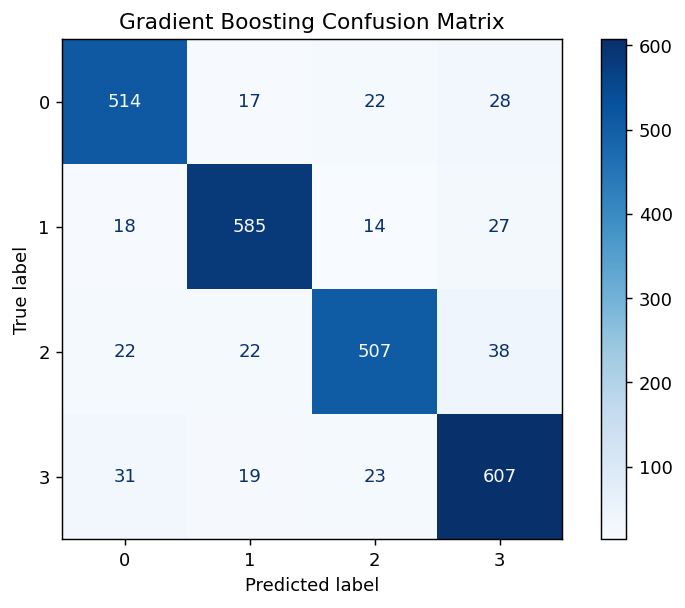

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Five-fold cross-validation

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_lr = cross_val_score(logistic_model, X, y, cv=cv, scoring="accuracy")
cv_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
    X, y, cv=cv, scoring="accuracy", n_jobs=1
)
cv_gb = cross_val_score(
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.15, max_depth=6, random_state=RANDOM_STATE),
    X, y, cv=cv, scoring="accuracy"
)

print(f"Logistic Regression: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"Random Forest:       {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"Gradient Boosting:   {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")

Logistic Regression: 0.2754 ± 0.0091
Random Forest:       0.8967 ± 0.0094
Gradient Boosting:   0.8964 ± 0.0128


## 13. Model comparison

In [22]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Test Accuracy": [acc_lr, acc_rf, acc_gb],
    "Weighted F1": [f1_lr, f1_rf, f1_gb],
    "CV Mean Accuracy": [cv_lr.mean(), cv_rf.mean(), cv_gb.mean()]
})

comparison

                 Model  Test Accuracy  Weighted F1  CV Mean Accuracy
0  Logistic Regression       0.266239     0.227929          0.275404
1        Random Forest       0.894146     0.894049          0.896705
2    Gradient Boosting       0.887330     0.887326          0.896384

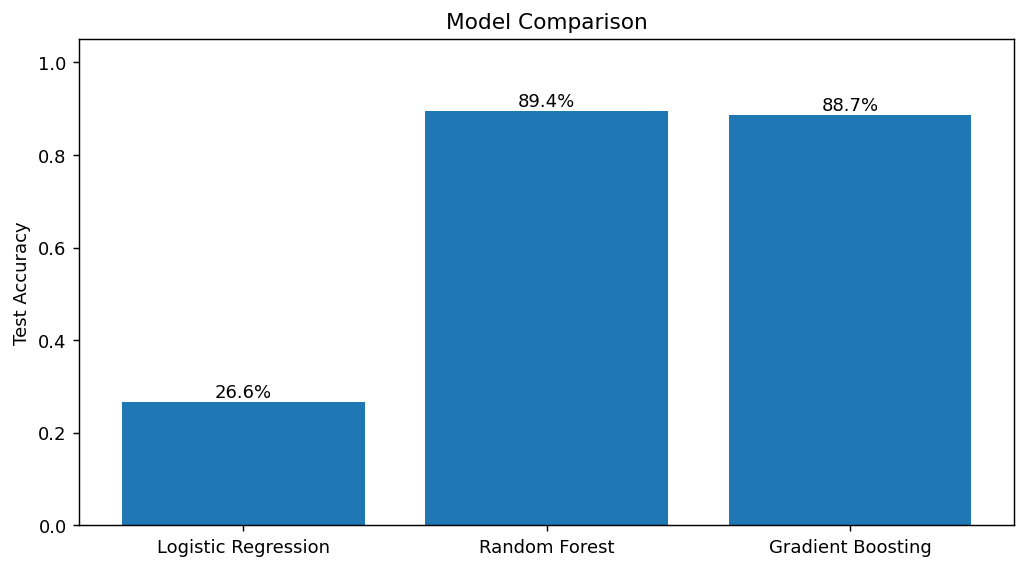

In [23]:
plt.figure(figsize=(8, 4.5))
bars = plt.bar(comparison["Model"], comparison["Test Accuracy"])
for bar, value in zip(bars, comparison["Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.01, f"{value:.1%}", ha="center")
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

## 14. Random Forest hyperparameter tuning

In [24]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [15, 25],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.8652


In [25]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"Tuned Random Forest accuracy: {acc_tuned:.4f}")
print(f"Tuned Random Forest weighted F1-score: {f1_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest accuracy: 0.8966
Tuned Random Forest weighted F1-score: 0.8965
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       581
           1       0.91      0.91      0.91       644
           2       0.91      0.87      0.89       589
           3       0.87      0.91      0.89       680

    accuracy                           0.90      2494
   macro avg       0.90      0.90      0.90      2494
weighted avg       0.90      0.90      0.90      2494



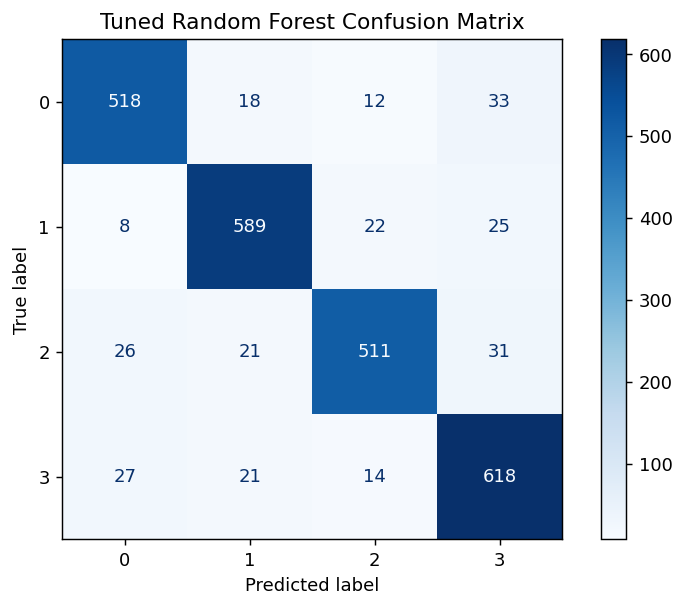

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, cmap="Blues")
plt.title("Tuned Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 15. Final validation

In [27]:
final_checks = pd.Series({
    "Original grade retained": "FinalGrade_Original" in df.columns,
    "Recoded grade used as target": TARGET == "FinalGrade",
    "ExamScore excluded from predictors": "ExamScore" not in X.columns,
    "Original grade excluded from predictors": "FinalGrade_Original" not in X.columns,
    "ExamScore–FinalGrade relationship is positive": recoded_corr > 0
})

final_checks

Original grade retained                          True
Recoded grade used as target                     True
ExamScore excluded from predictors               True
Original grade excluded from predictors          True
ExamScore–FinalGrade relationship is positive    True
dtype: bool